# **Solana Validator Behavior Analysis**

## **1) Load Initial Dataset**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.cloud import bigquery

client = bigquery.Client()

# Load selected features from vote account rows
query = """
SELECT
    node_pubkey,
    pubkey,
    block_timestamp,
    commission,
    lamports,
    root_slot,
    epoch_credits,
    votes,
    last_timestamp,
    authorized_voters,
    prior_voters,
    authorized_withdrawer,
    tx_signature,
    retrieval_timestamp,
    block_slot,
    block_hash,
    owner,
    account_type,
    rent_epoch,
    space
FROM `bigquery-public-data.crypto_solana_mainnet_us.Accounts`
WHERE account_type = 'vote'
"""

validators = client.query(query).to_dataframe()

validators.head()

,node_pubkey,pubkey,block_timestamp,commission,lamports,root_slot,epoch_credits,votes,last_timestamp,authorized_voters,prior_voters,authorized_withdrawer,tx_signature,retrieval_timestamp,block_slot,block_hash,owner,account_type,rent_epoch,space
0,93fX4gLgnUkcf3vmGBzuNKEt4em2tHxgmVcbq9vNq4jE,BJipnsRJCxgcMoYc7Env7ee2YASTtwLuyvD23AsJ3E6U,2022-02-11 19:14:50+00:00,10,26858640.000000000,212049884,"[{'credits': '53160681', 'epoch': 427, 'previo...","[{'confirmation_count': 31, 'slot': 212049885}...","[{'slot': 212049915, 'timestamp': 2023-08-17 2...",[{'authorized_voter': '93fX4gLgnUkcf3vmGBzuNKE...,"[{'authorized_pubkey': None, 'epoch_of_last_au...",H96haPy9G98ZVLYsSswPCzjbtUMwYVuN57g321226HsN,3mde3jcafA9YAVgeryVJqVB5BUNmX4yzkJdE64H8pGRpYV...,2023-08-17 22:50:48+00:00,120390489,6SebVUfyihefAJKTC3ckZteyiT2MoxRjgGoWctd8SFiY,Vote111111111111111111111111111111111111111,vote,361,3731
1,AxnCjA142ZKnA3uDLkgCQcjKNfjN784VDRvJpZ5jnUVx,GA9fZSG87xtpAr4kg6tHoQgihLjmaX22EmkiVKBWi8hH,2022-02-17 05:24:26+00:00,100,26858640.000000000,184065956,"[{'credits': '28856301', 'epoch': 363, 'previo...","[{'confirmation_count': 31, 'slot': 184065964}...","[{'slot': 184066003, 'timestamp': 2023-03-22 1...",[{'authorized_voter': 'AxnCjA142ZKnA3uDLkgCQcj...,[{'authorized_pubkey': 'AvGYUXkVdtn2Zjed7fk3BS...,AxnCjA142ZKnA3uDLkgCQcjKNfjN784VDRvJpZ5jnUVx,3GE22ZJPeAzvttyEUoEG6xqHCFFUbLj1M7TXjgKTokQdQv...,2023-08-18 07:12:06+00:00,121199863,FgMFNA72DWszWLcanWo2hWzXmV24DDrM2LzqrxTaWcJP,Vote111111111111111111111111111111111111111,vote,361,3731
2,FLAT3fBhQxrSPyT1zvyf58uQGARiGtnoN3VW8R7i38kC,EARTHZeTM64X3UMYf5rcWonQkTCn3uifEwutBx6e656K,2024-08-03 15:24:49+00:00,100,27074400.000000000,<NA>,"[{'credits': None, 'epoch': None, 'previous_cr...","[{'confirmation_count': None, 'slot': None}]","[{'slot': 0, 'timestamp': 1970-01-01 00:00:00+...",[{'authorized_voter': 'FLAT3fBhQxrSPyT1zvyf58u...,"[{'authorized_pubkey': None, 'epoch_of_last_au...",4bkJ8CnRUM8aEfPPWPxBxvXabfL2k2dzP2gBSX7ndHEq,2Y97aZxqFU7ae2ibopKHbAo7EQs6CDyCJVFFDN2xHtCSjU...,2024-08-03 16:58:19+00:00,281340972,8mhs38hVudEUW4oVebn68SZbrPhG8ZJHPnLVKAQwa7f8,Vote111111111111111111111111111111111111111,vote,-1,3762
3,EE1Noct5pwhvySzoW75dxZNqyT8i8nbHHjb4Sa2UE1SV,EwyiJLjZLa3rtW3s8iiERBcf22vbcWgrF5yEymK4pySV,2024-08-04 00:05:47+00:00,100,27074400.000000000,<NA>,"[{'credits': None, 'epoch': None, 'previous_cr...","[{'confirmation_count': None, 'slot': None}]","[{'slot': 0, 'timestamp': 1970-01-01 00:00:00+...",[{'authorized_voter': 'EE1Noct5pwhvySzoW75dxZN...,"[{'authorized_pubkey': None, 'epoch_of_last_au...",EZHdWwRbpm21MCid6w5DCNwKM1KNPEjg1Yovs1TRUfSV,Fp9FcesZyYNLZv32NpWjJqALTcaxT7ho6c4ywoGduW9gzy...,2024-08-04 01:24:45+00:00,281412140,CW2cp6rbnEiq6a8gJ9o6593dpZ2VoMhhQqrPcALADtxY,Vote111111111111111111111111111111111111111,vote,-1,3762
4,HSockkxSRQVqBUtEe19a7gpiUoheW8XLjeMD24kA8FHK,3EbZxx8VF3HCKfhXgY6GvNrP3EEJiTUAbAAaUpfTD49b,2024-08-22 23:14:16+00:00,0,27074400.000000000,<NA>,"[{'credits': None, 'epoch': None, 'previous_cr...","[{'confirmation_count': None, 'slot': None}]","[{'slot': 0, 'timestamp': 1970-01-01 00:00:00+...",[{'authorized_voter': 'HSockkxSRQVqBUtEe19a7gp...,"[{'authorized_pubkey': None, 'epoch_of_last_au...",6BvczpQjcnL3JKGSR8SbYuWYqSUJb3EbyvgnA6usqcNL,4RSWMRJrL2aL66LYm44emvJsvrXLeFNEC4mhvsMcxGoEu3...,2024-08-23 02:56:12+00:00,285232901,6315HLyjhn8JP3vdyqhvtddPpfgGdP8pxE9texpF9gZe,Vote111111111111111111111111111111111111111,vote,-1,3762


In [ ]:
# Sanity Check
print("Shape:", validators.shape)
print("\nColumns:")
print(validators.columns.tolist())

validators.info()

Shape: (9346, 20)

Columns:
['node_pubkey', 'pubkey', 'block_timestamp', 'commission', 'lamports', 'root_slot', 'epoch_credits', 'votes', 'last_timestamp', 'authorized_voters', 'prior_voters', 'authorized_withdrawer', 'tx_signature', 'retrieval_timestamp', 'block_slot', 'block_hash', 'owner', 'account_type', 'rent_epoch', 'space']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9346 entries, 0 to 9345
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype              
---  ------                 --------------  -----              
 0   node_pubkey            9346 non-null   object             
 1   pubkey                 9346 non-null   object             
 2   block_timestamp        9113 non-null   datetime64[us, UTC]
 3   commission             9346 non-null   Int64              
 4   lamports               9346 non-null   object             
 5   root_slot              4400 non-null   Int64              
 6   epoch_credits          9346 non-null   obje

## **2) Preliminary EDA**

### **2.1) Missingness**

In [ ]:
missing = pd.DataFrame({
    "missing_count": validators.isna().sum(),
    "missing_pct": validators.isna().mean() * 100
}).sort_values("missing_pct", ascending=False)

missing["non_missing_pct"] = 100 - missing["missing_pct"]

missing

,missing_count,missing_pct,non_missing_pct
root_slot,4946,52.921036,47.078964
block_timestamp,233,2.493045,97.506955
retrieval_timestamp,232,2.482345,97.517655
node_pubkey,0,0.000000,100.000000
commission,0,0.000000,100.000000
pubkey,0,0.000000,100.000000
epoch_credits,0,0.000000,100.000000
lamports,0,0.000000,100.000000
last_timestamp,0,0.000000,100.000000
authorized_voters,0,0.000000,100.000000


In [ ]:
# Deduplicate Validators (keep most recent snapshot per node)

print("Before deduplication:")
print(f"Rows: {len(validators):,}")
print(f"Unique validators: {validators['node_pubkey'].nunique():,}")
print(f"Duplicate rows: {len(validators) - validators['node_pubkey'].nunique():,}")

validators = (
    validators
    .sort_values("retrieval_timestamp")
    .drop_duplicates(
        subset="node_pubkey",
        keep="last"
    )
    .reset_index(drop=True)
)

print("\nAfter deduplication:")
print(f"Rows: {len(validators):,}")
print(f"Unique validators: {validators['node_pubkey'].nunique():,}")
print(f"Duplicate rows: {len(validators) - validators['node_pubkey'].nunique():,}")

Before deduplication:
Rows: 9,346
Unique validators: 8,577
Duplicate rows: 769

After deduplication:
Rows: 8,577
Unique validators: 8,577
Duplicate rows: 0


### **2.2) Distributions and Summary Statistics of Selected Features**

count                                8381
mean     2023-07-13 06:53:56.382412+00:00
min             2020-10-09 06:24:50+00:00
25%             2022-03-21 22:34:37+00:00
50%             2023-10-12 19:37:34+00:00
75%             2024-09-21 08:00:57+00:00
max             2026-06-15 21:45:47+00:00
Name: block_timestamp, dtype: object


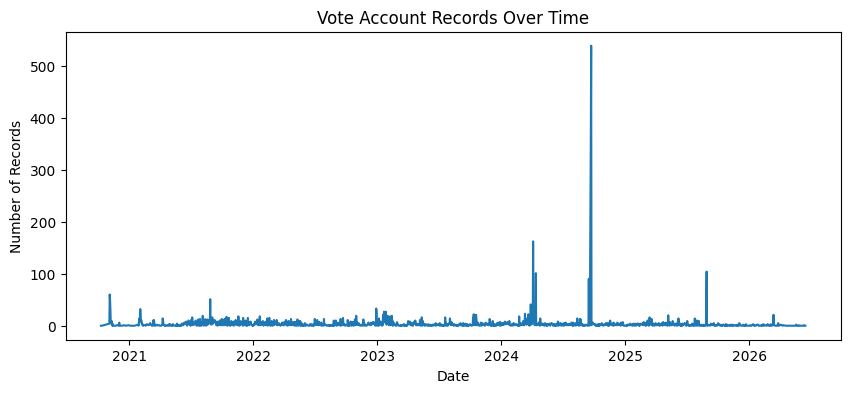

In [ ]:
# block_timestamp
validators["block_timestamp"] = pd.to_datetime(validators["block_timestamp"])

print(validators["block_timestamp"].describe())

validators["block_date"] = validators["block_timestamp"].dt.date

daily_counts = validators.groupby("block_date").size()

daily_counts.plot(figsize=(10, 4))
plt.title("Vote Account Records Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Records")
plt.show()

In [ ]:
# node_pubkey
print(validators["node_pubkey"].value_counts().describe())
print(validators["node_pubkey"].nunique())
validators["node_pubkey"].value_counts().head(20)

count    8577.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: count, dtype: float64
8577


,count
node_pubkey,
4daH8Aotxpk68HsMvws3P5AQL3F1gVTA44jqLaB2GuGx,1
6GRLDLiAtx8ZjYgQgPo7UsYeJ9g1pLX5j3HK97tFmtXb,1
94HgFvsD8zm7UXJ5KJxN4zW5nsdhZWY2LFREjfaFEHwR,1
EwUVzgSPe1zy2hfUGZxJAEP7Y1wheNgNsgratbzPELru,1
7aR6AjK87ehUxwEJrPpnoizUKtxJKxqZCQCEGD3h1Xgf,1
7XSCAfoJ11zrQxonjbGZHLUL8tqpF7yhkxiieLds9mdH,1
HwdfNWCqP2vXRvaHqQhoVUM2uPndaY8DDJzzBxCoPNHU,1
Drskw4YqMzYRVikgsGPACY1GnE4zTWs4uqSKajKdkU4Z,1
GRmtMtAeSL8HgX1p815ATQjaYU4Sk7XCP21i4yoFd3KS,1


count       8577.0
mean     57.764603
std      46.314182
min            0.0
25%           10.0
50%          100.0
75%          100.0
max          254.0
Name: commission, dtype: Float64

Missing: 0


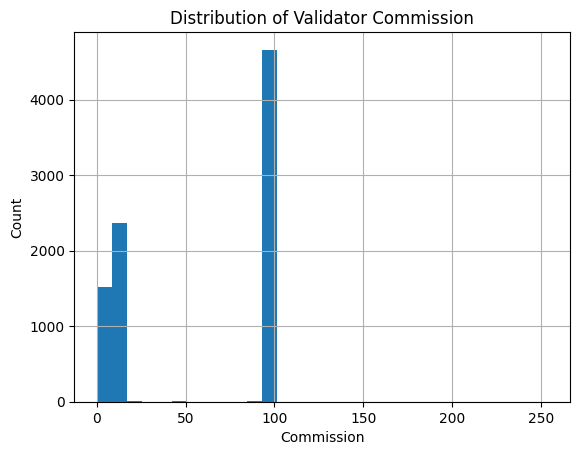

In [ ]:
# commission
print(validators["commission"].describe())
print("\nMissing:", validators["commission"].isna().sum())

validators["commission"].hist(bins=30)
plt.title("Distribution of Validator Commission")
plt.xlabel("Commission")
plt.ylabel("Count")
plt.show()

In [ ]:
validators["commission"].value_counts().sort_index()

,count
commission,
0,794
1,23
2,22
3,28
4,35
5,308
6,28
7,160
8,123


count    8.577000e+03
mean     1.239365e+11
std      3.669828e+12
min      2.685864e+07
1%       2.685864e+07
5%       2.685864e+07
25%      2.707440e+07
50%      2.707440e+07
75%      5.717475e+07
95%      4.519876e+10
99%      8.347674e+11
max      2.477528e+14
Name: lamports, dtype: float64


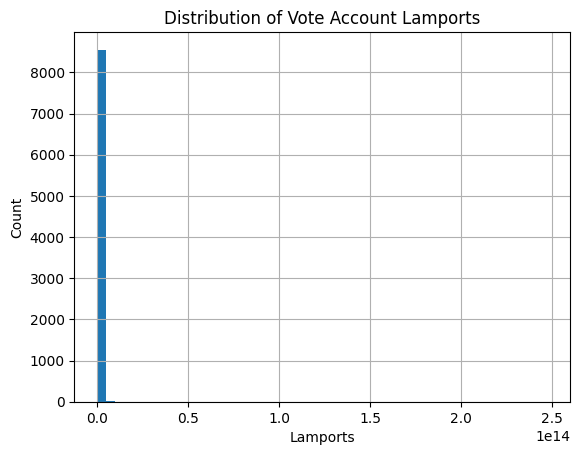

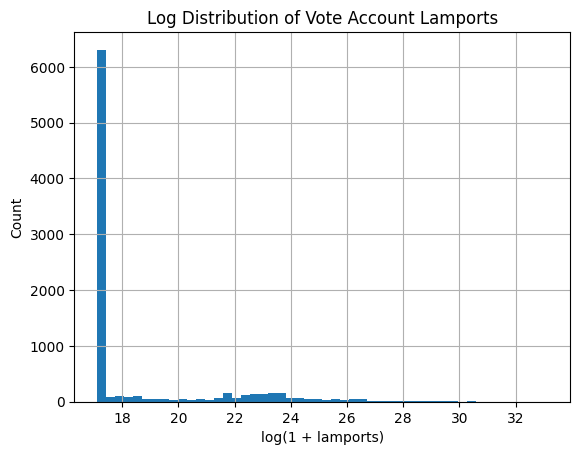

In [ ]:
# lamports
validators["lamports"] = pd.to_numeric(
    validators["lamports"],
    errors="coerce"
)

print(validators["lamports"].describe(

    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]

))

validators["lamports"].hist(bins=50)
plt.title("Distribution of Vote Account Lamports")
plt.xlabel("Lamports")
plt.ylabel("Count")
plt.show()

np.log1p(validators["lamports"].astype(float)).hist(bins=50)
plt.title("Log Distribution of Vote Account Lamports")
plt.xlabel("log(1 + lamports)")
plt.ylabel("Count")
plt.show()

count              4087.0
mean     199300966.594323
std       51814005.345136
min             7829113.0
25%           182357814.5
50%           210527864.0
75%           215468959.0
max           426718444.0
Name: root_slot, dtype: Float64

Missing: 4490


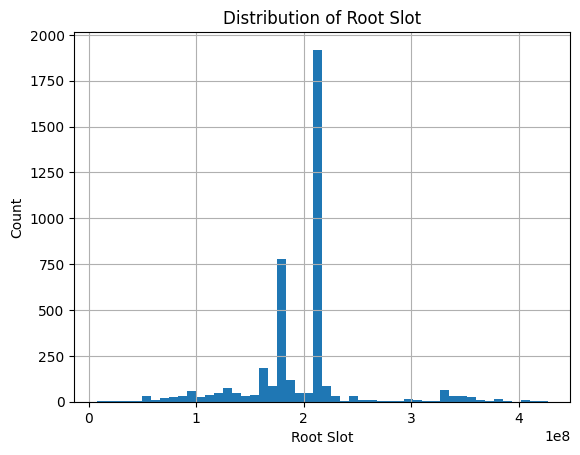

In [ ]:
# root_slot
print(validators["root_slot"].describe())
print("\nMissing:", validators["root_slot"].isna().sum())

validators["root_slot"].hist(bins=50)
plt.title("Distribution of Root Slot")
plt.xlabel("Root Slot")
plt.ylabel("Count")
plt.show()

count    8577.000000
mean       23.243092
std        29.173356
min         0.000000
25%         1.000000
50%         1.000000
75%        64.000000
max        64.000000
Name: num_epoch_credit_records, dtype: float64

Missing: 0


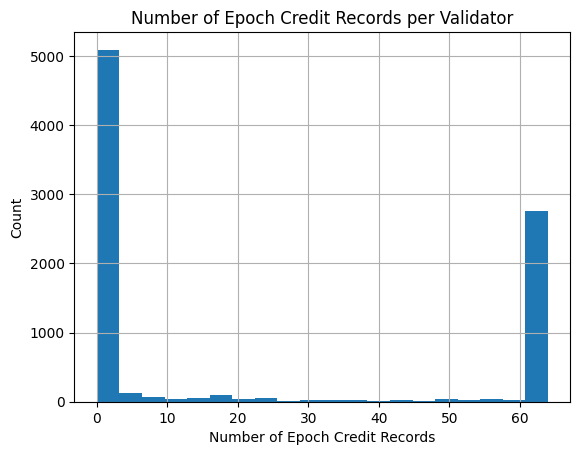

,node_pubkey,epoch_credits,num_epoch_credit_records
0,BvXzmS5rLW89nHD7K2qVjcERKigDdJ8Xhc74MQZumj9J,"[{'credits': '22632340', 'epoch': 191, 'previo...",64
1,G9KGpYSQZxvEZb3YD7qK9wpUvqXcCTfbx278kj4cQC49,"[{'credits': '15597', 'epoch': 95, 'previous_c...",1
2,9gFxqsXbFyrKXUkqpAatonn47uYZ7sEZSnMxhzQoXrUJ,"[{'credits': '106926603', 'epoch': 422, 'previ...",64
3,CBUGET5PnvLc3HvEeFYj64iTvdKhYV6pujTPDdDh785K,"[{'credits': '107924085', 'epoch': 422, 'previ...",64
4,2vo82HJubX8Yx2VoCpZupfdtu9miYCrh8A1P3YJXRP25,"[{'credits': '88106063', 'epoch': 372, 'previo...",64


In [ ]:
# epoch_credits
validators["num_epoch_credit_records"] = validators["epoch_credits"].apply(
    lambda x: len(x) if isinstance(x, (list, np.ndarray)) else 0
)

print(validators["num_epoch_credit_records"].describe())
print("\nMissing:", validators["epoch_credits"].isna().sum())

validators["num_epoch_credit_records"].hist(bins=20)
plt.title("Number of Epoch Credit Records per Validator")
plt.xlabel("Number of Epoch Credit Records")
plt.ylabel("Count")
plt.show()

validators[["node_pubkey", "epoch_credits", "num_epoch_credit_records"]].head()

In [ ]:
# epoch_credits (nested data)
# Show full epoch credit records

for i in range(5):
    print(f"\nValidator {i}")
    print("Node:", validators.iloc[i]["node_pubkey"])
    print("Epoch Credits:")

    for record in validators.iloc[i]["epoch_credits"]:
        print(record)

    print("-" * 80)


Validator 0
Node: BvXzmS5rLW89nHD7K2qVjcERKigDdJ8Xhc74MQZumj9J
Epoch Credits:
{'credits': '22632340', 'epoch': 191, 'previous_credits': '22382011'}
{'credits': '22880139', 'epoch': 192, 'previous_credits': '22632340'}
{'credits': '23120333', 'epoch': 193, 'previous_credits': '22880139'}
{'credits': '23349776', 'epoch': 194, 'previous_credits': '23120333'}
{'credits': '23578030', 'epoch': 195, 'previous_credits': '23349776'}
{'credits': '23799062', 'epoch': 196, 'previous_credits': '23578030'}
{'credits': '24007110', 'epoch': 197, 'previous_credits': '23799062'}
{'credits': '24221509', 'epoch': 198, 'previous_credits': '24007110'}
{'credits': '24425975', 'epoch': 199, 'previous_credits': '24221509'}
{'credits': '24625982', 'epoch': 200, 'previous_credits': '24425975'}
{'credits': '24822754', 'epoch': 201, 'previous_credits': '24625982'}
{'credits': '24998107', 'epoch': 202, 'previous_credits': '24822754'}
{'credits': '25163754', 'epoch': 203, 'previous_credits': '24998107'}
{'credits':

count    8577.000000
mean       15.278769
std        14.974233
min         0.000000
25%         1.000000
50%         1.000000
75%        31.000000
max        31.000000
Name: num_vote_records, dtype: float64

Missing: 0


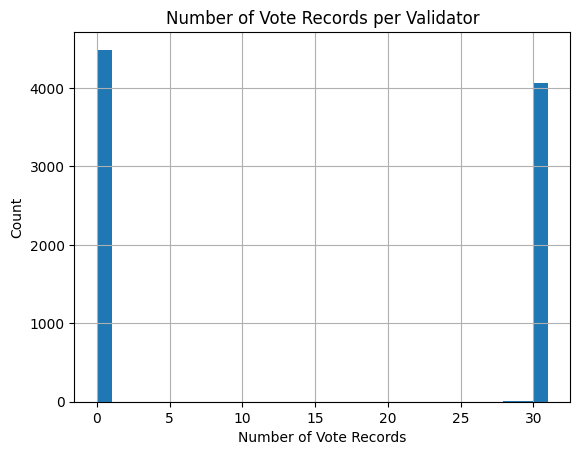

,node_pubkey,votes,num_vote_records
0,BvXzmS5rLW89nHD7K2qVjcERKigDdJ8Xhc74MQZumj9J,"[{'confirmation_count': 31, 'slot': 109919020}...",31
1,G9KGpYSQZxvEZb3YD7qK9wpUvqXcCTfbx278kj4cQC49,"[{'confirmation_count': 31, 'slot': 41112363},...",31
2,9gFxqsXbFyrKXUkqpAatonn47uYZ7sEZSnMxhzQoXrUJ,"[{'confirmation_count': 31, 'slot': 209756903}...",31
3,CBUGET5PnvLc3HvEeFYj64iTvdKhYV6pujTPDdDh785K,"[{'confirmation_count': 31, 'slot': 209757056}...",31
4,2vo82HJubX8Yx2VoCpZupfdtu9miYCrh8A1P3YJXRP25,"[{'confirmation_count': 31, 'slot': 188536626}...",31


In [ ]:
# votes
validators["num_vote_records"] = validators["votes"].apply(
    lambda x: len(x) if isinstance(x, (list, np.ndarray)) else 0
)

print(validators["num_vote_records"].describe())
print("\nMissing:", validators["votes"].isna().sum())

validators["num_vote_records"].hist(bins=30)
plt.title("Number of Vote Records per Validator")
plt.xlabel("Number of Vote Records")
plt.ylabel("Count")
plt.show()

validators[["node_pubkey", "votes", "num_vote_records"]].head()

In [ ]:
for i in range(5):
    print(f"\nValidator {i}")
    print("Node:", validators.iloc[i]["node_pubkey"])
    print("Votes:")

    votes = validators.iloc[i]["votes"]

    if len(votes) > 0:
        for vote in votes:
            print(vote)
    else:
        print("No votes")

    print("-" * 80)


Validator 0
Node: BvXzmS5rLW89nHD7K2qVjcERKigDdJ8Xhc74MQZumj9J
Votes:
{'confirmation_count': 31, 'slot': 109919020}
{'confirmation_count': 30, 'slot': 109919052}
{'confirmation_count': 29, 'slot': 109919068}
{'confirmation_count': 28, 'slot': 109919076}
{'confirmation_count': 27, 'slot': 109919080}
{'confirmation_count': 26, 'slot': 109919082}
{'confirmation_count': 25, 'slot': 109919083}
{'confirmation_count': 24, 'slot': 109919084}
{'confirmation_count': 23, 'slot': 109919085}
{'confirmation_count': 22, 'slot': 109919086}
{'confirmation_count': 21, 'slot': 109919087}
{'confirmation_count': 20, 'slot': 109919088}
{'confirmation_count': 19, 'slot': 109919089}
{'confirmation_count': 18, 'slot': 109919090}
{'confirmation_count': 17, 'slot': 109919091}
{'confirmation_count': 16, 'slot': 109919092}
{'confirmation_count': 15, 'slot': 109919093}
{'confirmation_count': 14, 'slot': 109919094}
{'confirmation_count': 13, 'slot': 109919095}
{'confirmation_count': 12, 'slot': 109919096}
{'confirm

In [ ]:
# last_timestamp
"""validators["num_last_timestamp_records"] = validators["last_timestamp"].apply(
    lambda x: len(x) if isinstance(x, (list, np.ndarray)) else 0
)

print(validators["num_last_timestamp_records"].describe())
print("\nMissing:", validators["last_timestamp"].isna().sum())

validators[["node_pubkey", "last_timestamp", "num_last_timestamp_records"]].head()"""

'validators["num_last_timestamp_records"] = validators["last_timestamp"].apply(\n    lambda x: len(x) if isinstance(x, (list, np.ndarray)) else 0\n)\n\nprint(validators["num_last_timestamp_records"].describe())\nprint("\nMissing:", validators["last_timestamp"].isna().sum())\n\nvalidators[["node_pubkey", "last_timestamp", "num_last_timestamp_records"]].head()'

Latest Vote Slot
count    8.577000e+03
mean     9.492087e+07
std      1.057380e+08
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      2.097584e+08
max      4.267185e+08
Name: latest_vote_slot, dtype: float64

Latest Vote Timestamp
count                                   8577
mean     1995-06-13 22:48:46.665267584+00:00
min                1970-01-01 00:00:00+00:00
25%                1970-01-01 00:00:00+00:00
50%                1970-01-01 00:00:00+00:00
75%                2023-08-06 08:14:02+00:00
max                2026-06-15 21:45:48+00:00
Name: latest_vote_timestamp, dtype: object

Missing Slots: 0
Missing Timestamps: 0


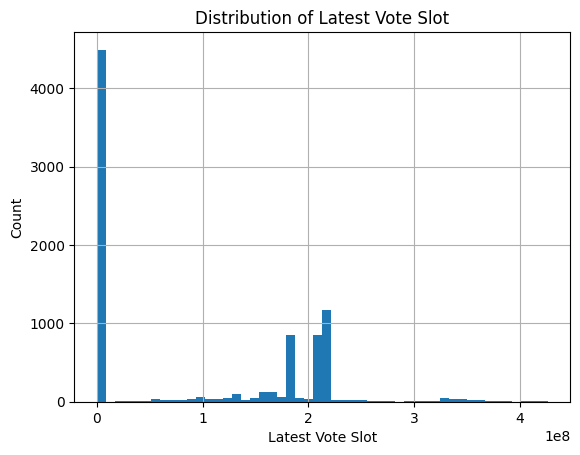

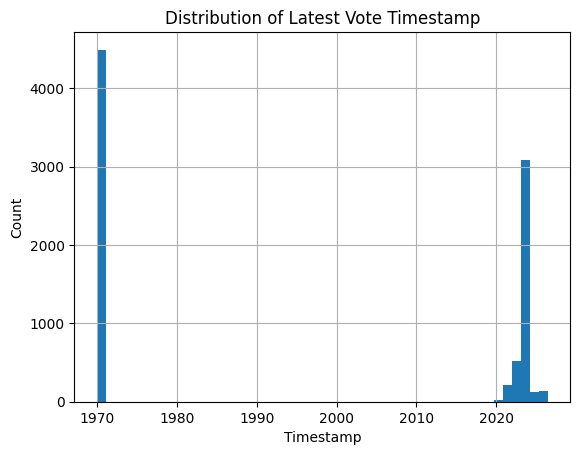

In [ ]:
# last_timestamp EDA

def extract_last_vote_slot(x):
    if x is None:
        return np.nan

    if isinstance(x, np.ndarray):
        x = x.tolist()

    if isinstance(x, list) and len(x) > 0:
        record = x[0]
        if isinstance(record, dict):
            return record.get("slot")

    return np.nan


def extract_last_vote_timestamp(x):
    if x is None:
        return pd.NaT

    if isinstance(x, np.ndarray):
        x = x.tolist()

    if isinstance(x, list) and len(x) > 0:
        record = x[0]
        if isinstance(record, dict):
            return pd.to_datetime(record.get("timestamp"), errors="coerce")

    return pd.NaT


validators["latest_vote_slot"] = validators["last_timestamp"].apply(extract_last_vote_slot)
validators["latest_vote_timestamp"] = validators["last_timestamp"].apply(extract_last_vote_timestamp)

validators["latest_vote_slot"] = pd.to_numeric(validators["latest_vote_slot"], errors="coerce")

print("Latest Vote Slot")
print(validators["latest_vote_slot"].describe())

print("\nLatest Vote Timestamp")
print(validators["latest_vote_timestamp"].describe())

print("\nMissing Slots:", validators["latest_vote_slot"].isna().sum())
print("Missing Timestamps:", validators["latest_vote_timestamp"].isna().sum())

validators[["node_pubkey", "last_timestamp", "latest_vote_slot", "latest_vote_timestamp"]].head()

# Distribution of latest vote slot

validators["latest_vote_slot"].hist(bins=50)

plt.title("Distribution of Latest Vote Slot")
plt.xlabel("Latest Vote Slot")
plt.ylabel("Count")
plt.show()


# Distribution of latest vote timestamp

validators["latest_vote_timestamp"] = pd.to_datetime(
    validators["latest_vote_timestamp"],
    errors="coerce"
)

validators["latest_vote_timestamp"].hist(bins=50)

plt.title("Distribution of Latest Vote Timestamp")
plt.xlabel("Timestamp")
plt.ylabel("Count")
plt.show()

count    8577.000000
mean        1.006179
std         0.078370
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         2.000000
Name: num_authorized_voters, dtype: float64

Missing: 0


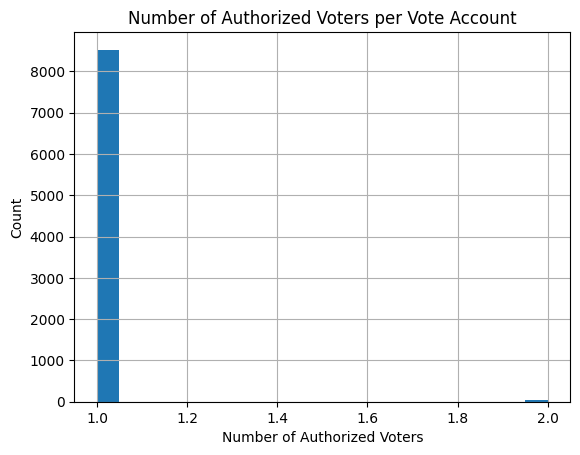

,node_pubkey,authorized_voters,num_authorized_voters
0,BvXzmS5rLW89nHD7K2qVjcERKigDdJ8Xhc74MQZumj9J,[{'authorized_voter': 'BvXzmS5rLW89nHD7K2qVjcE...,1
1,G9KGpYSQZxvEZb3YD7qK9wpUvqXcCTfbx278kj4cQC49,[{'authorized_voter': 'EZ3fJExBfbviJCbLjd57agc...,2
2,9gFxqsXbFyrKXUkqpAatonn47uYZ7sEZSnMxhzQoXrUJ,[{'authorized_voter': '9gFxqsXbFyrKXUkqpAatonn...,1
3,CBUGET5PnvLc3HvEeFYj64iTvdKhYV6pujTPDdDh785K,[{'authorized_voter': 'CBUGET5PnvLc3HvEeFYj64i...,1
4,2vo82HJubX8Yx2VoCpZupfdtu9miYCrh8A1P3YJXRP25,[{'authorized_voter': '2vo82HJubX8Yx2VoCpZupfd...,1


In [ ]:
# authorized_voters
validators["num_authorized_voters"] = validators["authorized_voters"].apply(
    lambda x: len(x) if isinstance(x, (list, np.ndarray)) else 0
)

print(validators["num_authorized_voters"].describe())
print("\nMissing:", validators["authorized_voters"].isna().sum())

validators["num_authorized_voters"].hist(bins=20)
plt.title("Number of Authorized Voters per Vote Account")
plt.xlabel("Number of Authorized Voters")
plt.ylabel("Count")
plt.show()

validators[["node_pubkey", "authorized_voters", "num_authorized_voters"]].head()

count    8577.000000
mean        1.001282
std         0.094747
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         5.000000
Name: num_prior_voters, dtype: float64

Missing: 0


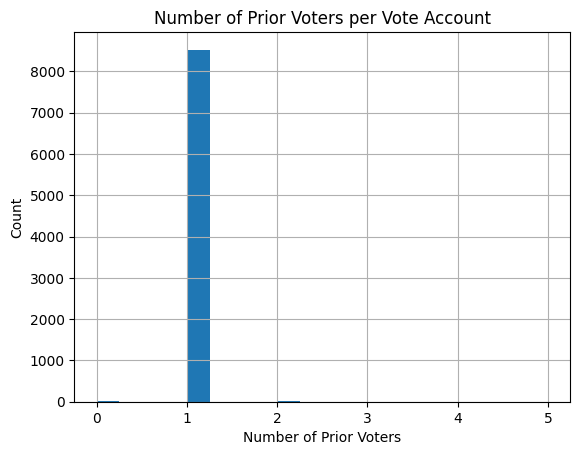

,node_pubkey,prior_voters,num_prior_voters
0,BvXzmS5rLW89nHD7K2qVjcERKigDdJ8Xhc74MQZumj9J,"[{'authorized_pubkey': None, 'epoch_of_last_au...",1
1,G9KGpYSQZxvEZb3YD7qK9wpUvqXcCTfbx278kj4cQC49,[{'authorized_pubkey': 'EZ3fJExBfbviJCbLjd57ag...,1
2,9gFxqsXbFyrKXUkqpAatonn47uYZ7sEZSnMxhzQoXrUJ,"[{'authorized_pubkey': None, 'epoch_of_last_au...",1
3,CBUGET5PnvLc3HvEeFYj64iTvdKhYV6pujTPDdDh785K,"[{'authorized_pubkey': None, 'epoch_of_last_au...",1
4,2vo82HJubX8Yx2VoCpZupfdtu9miYCrh8A1P3YJXRP25,[{'authorized_pubkey': '3LKjD9Cb8RKKbmwM3LphHE...,1


In [ ]:
# prior_voters
validators["num_prior_voters"] = validators["prior_voters"].apply(
    lambda x: len(x) if isinstance(x, (list, np.ndarray)) else 0
)

print(validators["num_prior_voters"].describe())
print("\nMissing:", validators["prior_voters"].isna().sum())

validators["num_prior_voters"].hist(bins=20)
plt.title("Number of Prior Voters per Vote Account")
plt.xlabel("Number of Prior Voters")
plt.ylabel("Count")
plt.show()

validators[["node_pubkey", "prior_voters", "num_prior_voters"]].head()

count        8577.0
mean     125.657223
std      172.441631
min            -1.0
25%            -1.0
50%             0.0
75%           361.0
max           361.0
Name: rent_epoch, dtype: Float64

Missing: 0


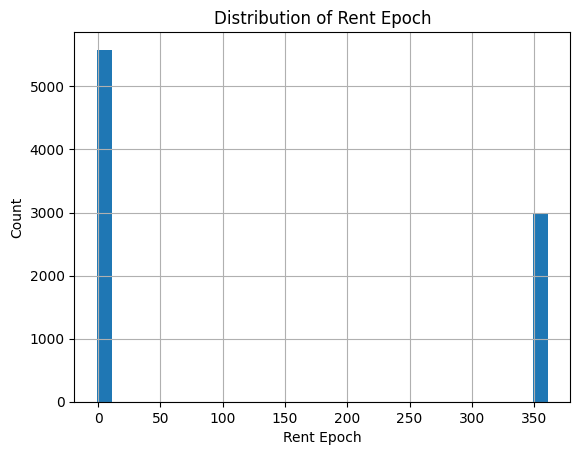

In [ ]:
# rent_epoch
print(validators["rent_epoch"].describe())
print("\nMissing:", validators["rent_epoch"].isna().sum())

validators["rent_epoch"].hist(bins=30)
plt.title("Distribution of Rent Epoch")
plt.xlabel("Rent Epoch")
plt.ylabel("Count")
plt.show()

count         8577.0
mean     3744.145272
std        15.320986
min           3731.0
25%           3731.0
50%           3731.0
75%           3762.0
max           3762.0
Name: space, dtype: Float64

Missing: 0


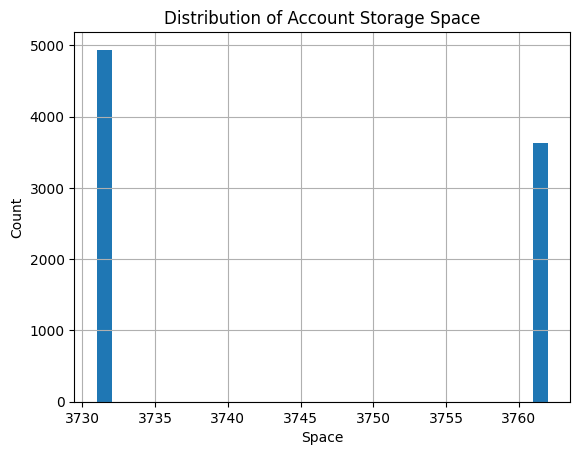

In [ ]:
# space
print(validators["space"].describe())
print("\nMissing:", validators["space"].isna().sum())

validators["space"].hist(bins=30)
plt.title("Distribution of Account Storage Space")
plt.xlabel("Space")
plt.ylabel("Count")
plt.show()

## **3) Preprocessing and Feature Engineering**

### **3.1) Feature Engineering and Validation**

In [ ]:
# Epoch Helper Function
MAX_EPOCH_CREDITS = 6912000

def get_epoch_deltas(epoch_credit_records):
    """
    Returns epoch credit gains for each recorded epoch.
    """

    if not isinstance(epoch_credit_records, (list, np.ndarray)):
        return []

    deltas = []

    for record in epoch_credit_records:
        try:
            credits = int(record["credits"])
            prev = int(record["previous_credits"])
            deltas.append(credits - prev)
        except:
            continue

    return deltas

In [ ]:
# Mean Efficiency
validators["mean_efficiency_pct"] = validators["epoch_credits"].apply(
    lambda x: (
        np.mean(get_epoch_deltas(x)) / MAX_EPOCH_CREDITS * 100
    )
    if len(get_epoch_deltas(x)) > 0
    else np.nan
)

validators["mean_efficiency_pct"].describe()

,mean_efficiency_pct
count,4087.000000
mean,6.695356
std,11.631324
min,0.000000
25%,4.978697
50%,5.421566
75%,5.898915
max,99.535120


In [ ]:
# Median Efficiency
validators["median_efficiency_pct"] = validators["epoch_credits"].apply(
    lambda x: (
        np.median(get_epoch_deltas(x)) / MAX_EPOCH_CREDITS * 100
    )
    if len(get_epoch_deltas(x)) > 0
    else np.nan
)

validators["median_efficiency_pct"].describe()

,median_efficiency_pct
count,4087.000000
mean,6.935442
std,12.490385
min,0.000000
25%,5.170048
50%,5.821774
75%,5.988686
max,99.867607


In [ ]:
def efficiency_cv(epoch_credit_records):

    deltas = get_epoch_deltas(epoch_credit_records)

    if len(deltas) < 2:
        return np.nan

    mean = np.mean(deltas)

    if mean == 0:
        return np.nan

    return np.std(deltas) / mean


validators["efficiency_cv"] = validators["epoch_credits"].apply(
    efficiency_cv
)

validators["efficiency_cv"].describe()

,efficiency_cv
count,3735.000000
mean,0.178416
std,0.199103
min,0.007306
25%,0.074349
50%,0.116663
75%,0.188402
max,1.486126


In [ ]:
# Performance Trend
def performance_trend(epoch_credit_records):

    deltas = get_epoch_deltas(epoch_credit_records)

    if len(deltas) < 4:
        return np.nan

    efficiencies = np.array(deltas) / MAX_EPOCH_CREDITS * 100

    midpoint = len(efficiencies) // 2

    first_half = efficiencies[:midpoint]
    second_half = efficiencies[midpoint:]

    return np.mean(second_half) - np.mean(first_half)


validators["performance_trend"] = validators["epoch_credits"].apply(
    performance_trend
)

validators["performance_trend"].describe()

,performance_trend
count,3485.000000
mean,0.110452
std,3.061183
min,-25.092860
25%,-0.349915
50%,-0.057729
75%,0.049051
max,68.457862


In [ ]:
# Number of Epochs
validators["num_epochs_recorded"] = validators["epoch_credits"].apply(
    lambda x: len(x)
    if isinstance(x, (list, np.ndarray))
    else 0
)

validators["num_epochs_recorded"].describe()

,num_epochs_recorded
count,8577.000000
mean,23.243092
std,29.173356
min,0.000000
25%,1.000000
50%,1.000000
75%,64.000000
max,64.000000


In [ ]:
# Log Lamports
validators["log_lamports"] = np.log10(
    validators["lamports"] + 1
)

validators["log_lamports"].describe()

,log_lamports
count,8577.000000
mean,8.035000
std,1.184306
min,7.429084
25%,7.432559
50%,7.432559
75%,7.757204
max,14.394019


In [ ]:
validators["num_authorized_voters"] = validators["authorized_voters"].apply(
    lambda x: len(x)
    if isinstance(x, (list, np.ndarray))
    else 0
)

validators["num_authorized_voters"].describe()

,num_authorized_voters
count,8577.000000
mean,1.006179
std,0.078370
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,2.000000


In [ ]:
validators["num_prior_voters"] = validators["prior_voters"].apply(
    lambda x: len(x)
    if isinstance(x, (list, np.ndarray))
    else 0
)

validators["num_prior_voters"].describe()

,num_prior_voters
count,8577.000000
mean,1.001282
std,0.094747
min,0.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,5.000000


In [ ]:
# Establish Candidate Feature Set
candidate_features = [
    "commission",
    "log_lamports",
    "mean_efficiency_pct",
    "median_efficiency_pct",
    "efficiency_cv",
    "performance_trend",
    "num_epochs_recorded",
    "num_authorized_voters",
    "num_prior_voters"
]

validators[candidate_features].describe()

,commission,log_lamports,mean_efficiency_pct,median_efficiency_pct,efficiency_cv,performance_trend,num_epochs_recorded,num_authorized_voters,num_prior_voters
count,8577.0,8577.000000,4087.000000,4087.000000,3735.000000,3485.000000,8577.000000,8577.000000,8577.000000
mean,57.764603,8.035000,6.695356,6.935442,0.178416,0.110452,23.243092,1.006179,1.001282
std,46.314182,1.184306,11.631324,12.490385,0.199103,3.061183,29.173356,0.078370,0.094747
min,0.0,7.429084,0.000000,0.000000,0.007306,-25.092860,0.000000,1.000000,0.000000
25%,10.0,7.432559,4.978697,5.170048,0.074349,-0.349915,1.000000,1.000000,1.000000
50%,100.0,7.432559,5.421566,5.821774,0.116663,-0.057729,1.000000,1.000000,1.000000
75%,100.0,7.757204,5.898915,5.988686,0.188402,0.049051,64.000000,1.000000,1.000000
max,254.0,14.394019,99.535120,99.867607,1.486126,68.457862,64.000000,2.000000,5.000000


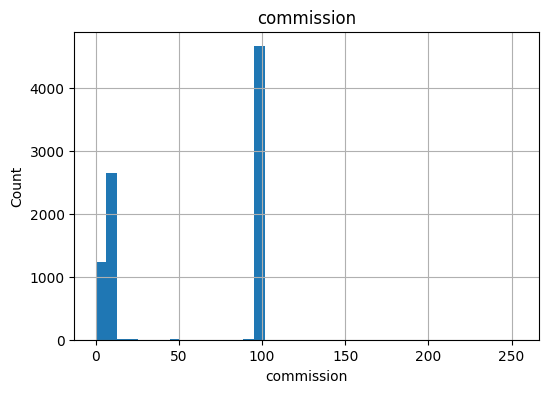

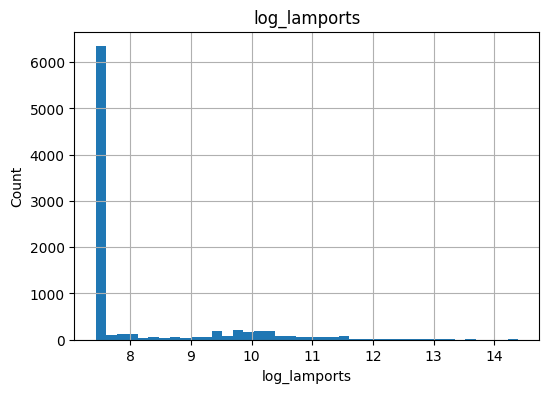

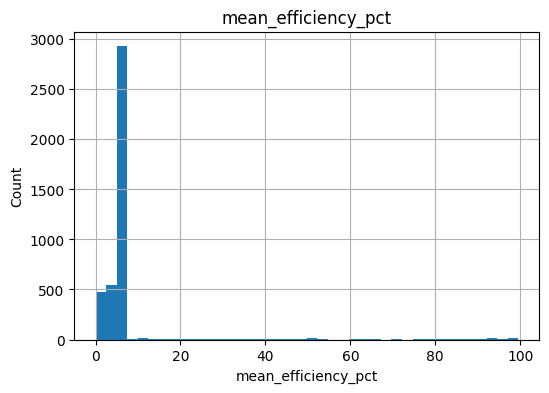

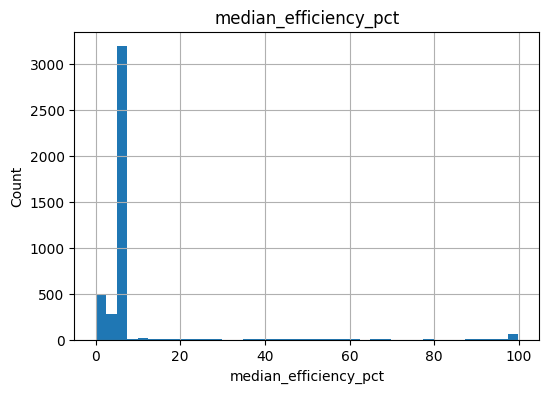

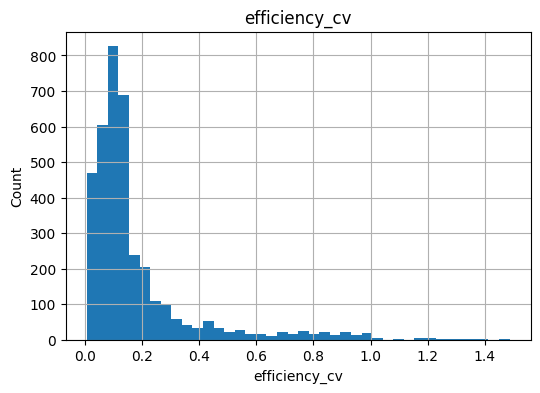

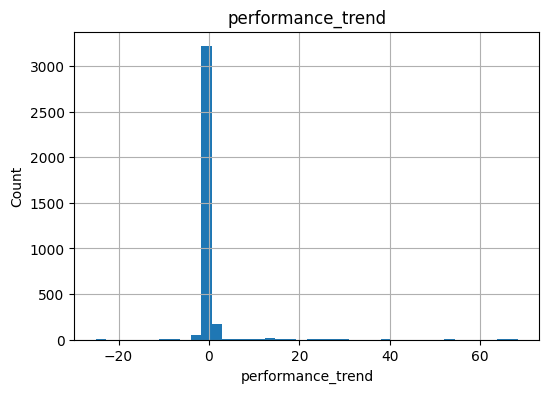

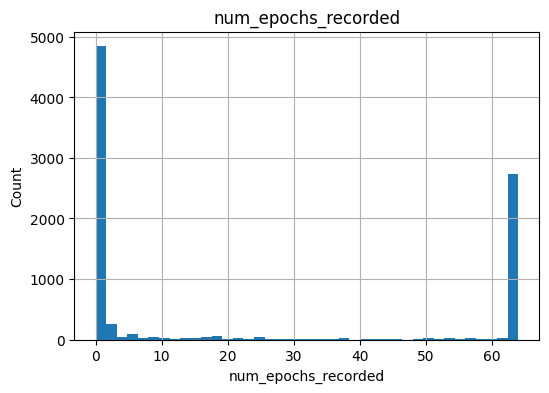

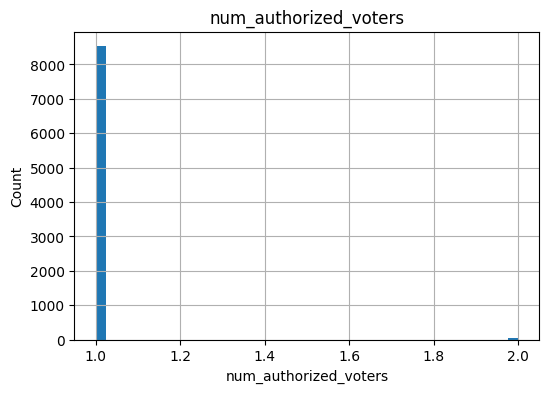

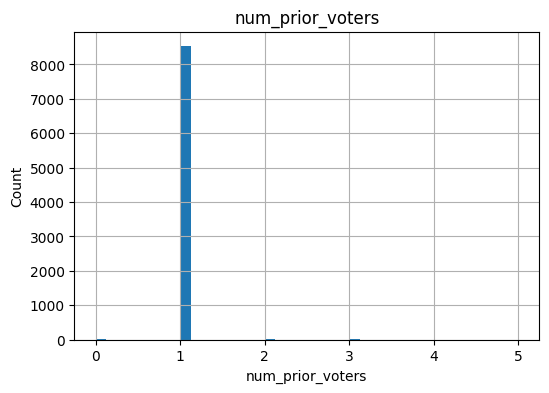

In [ ]:
# Plot Distributions of Candidate Set
import matplotlib.pyplot as plt

for feature in candidate_features:

    plt.figure(figsize=(6,4))

    validators[feature].hist(bins=40)

    plt.title(feature)
    plt.xlabel(feature)
    plt.ylabel("Count")

    plt.show()

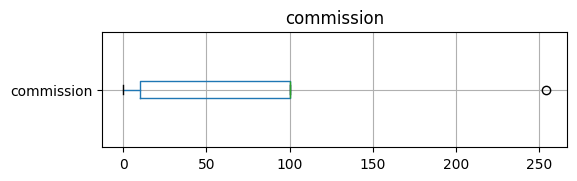

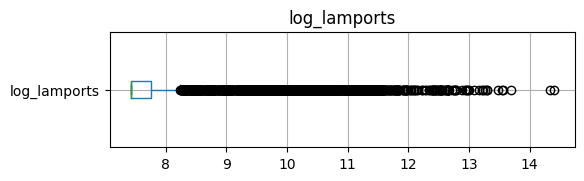

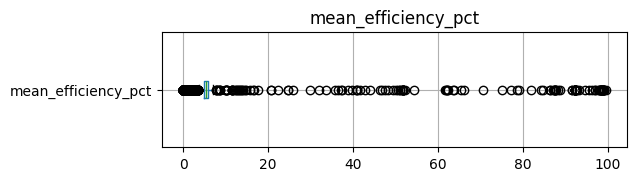

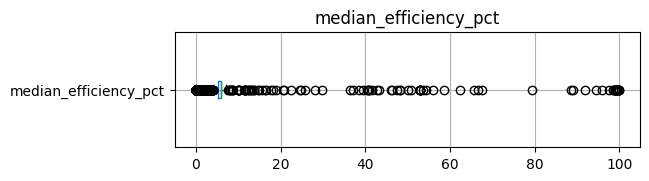

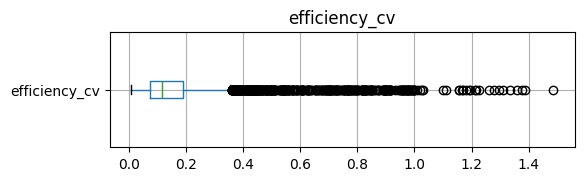

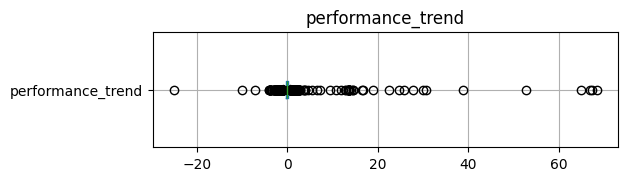

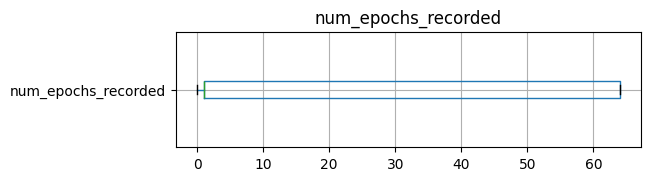

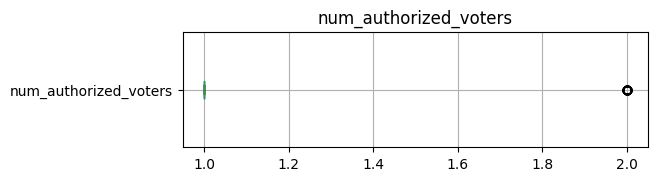

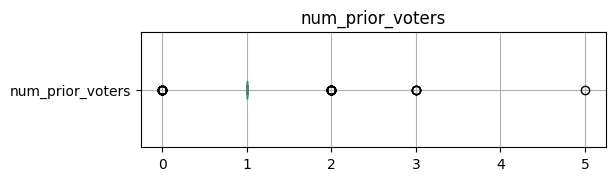

In [ ]:
for feature in candidate_features:

    plt.figure(figsize=(6,1.5))

    validators.boxplot(column=feature, vert=False)

    plt.title(feature)

    plt.show()

In [ ]:
# Remove the single invalid commission observation
validators = validators[validators["commission"] <= 100].copy()

In [ ]:
# Remove Governance Features
candidate_features = [
    "commission",
    "log_lamports",
    "mean_efficiency_pct",
    "median_efficiency_pct",
    "efficiency_cv",
    "performance_trend",
    "num_epochs_recorded"
]

In [ ]:
print(validators[candidate_features].isna().sum())
print(validators[candidate_features].dropna().shape)

commission                  0
log_lamports                0
mean_efficiency_pct      4490
median_efficiency_pct    4490
efficiency_cv            4842
performance_trend        5092
num_epochs_recorded         0
dtype: int64
(3484, 7)


In [ ]:
# Handle Missing Performance History

# History indicator
validators["has_history"] = (
    validators["num_epochs_recorded"] > 1
).astype(int)

# Median CV from validators with actual history
cv_median = validators.loc[
    validators["has_history"] == 1,
    "efficiency_cv"
].median()

# Impute performance metrics
validators["median_efficiency_pct"] = (
    validators["median_efficiency_pct"]
    .fillna(0)
)

validators["performance_trend"] = (
    validators["performance_trend"]
    .fillna(0)
)

validators["efficiency_cv"] = (
    validators["efficiency_cv"]
    .fillna(cv_median)
)

candidate_features = [
    "commission",
    "log_lamports",
    "median_efficiency_pct",
    "efficiency_cv",
    "performance_trend",
    "num_epochs_recorded",
    "has_history"
]

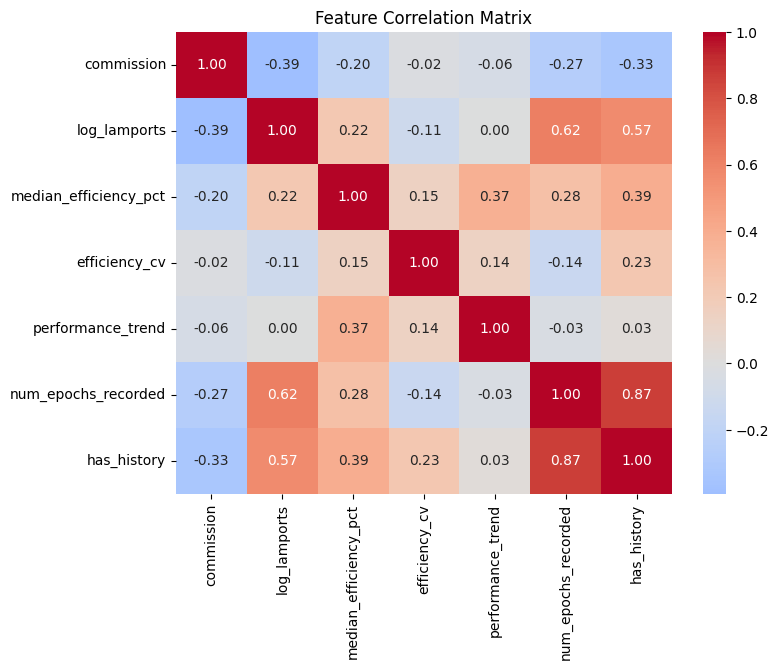

In [ ]:
# Correlation Matrix / Heatmap of Candidate Features
corr_matrix = validators[candidate_features].corr()

corr_matrix

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")
plt.show()

## **4) PCA and Dimensionality Reduction**

In [ ]:
# Scaling
from sklearn.preprocessing import StandardScaler

X = validators[candidate_features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled.shape

(8576, 7)

In [ ]:
# Fit PCA
from sklearn.decomposition import PCA
import pandas as pd

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_var = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(candidate_features))],
    "Explained Variance": pca.explained_variance_ratio_,
    "Cumulative Variance": pca.explained_variance_ratio_.cumsum()
})

explained_var

,PC,Explained Variance,Cumulative Variance
0,PC1,0.395647,0.395647
1,PC2,0.202149,0.597797
2,PC3,0.137844,0.735640
3,PC4,0.118623,0.854263
4,PC5,0.078588,0.932851
5,PC6,0.059138,0.991988
6,PC7,0.008012,1.000000


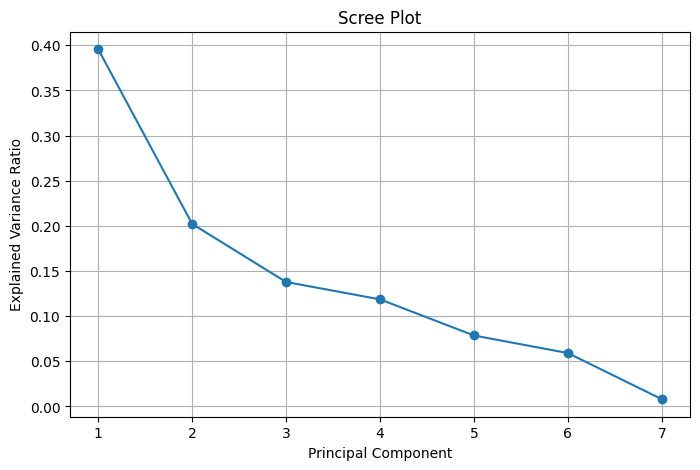

In [ ]:
# Scree Plot (How many dimensions do we need?)
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(candidate_features)+1),
    pca.explained_variance_ratio_,
    marker="o"
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")

plt.grid(True)

plt.show()

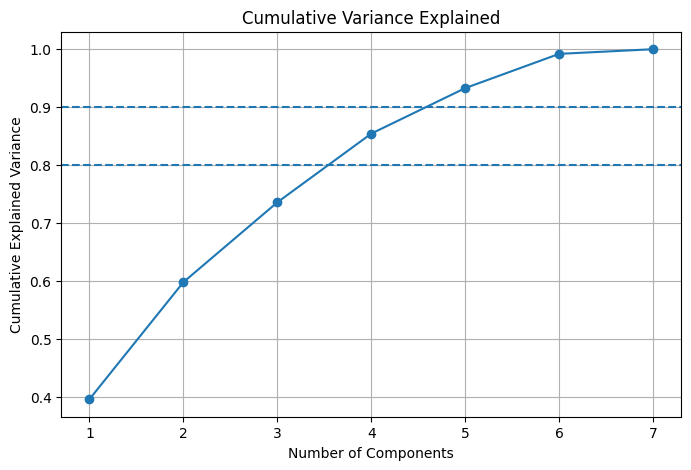

In [ ]:
# Cumulative Variance Plot
plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(candidate_features)+1),
    np.cumsum(pca.explained_variance_ratio_),
    marker="o"
)

plt.axhline(0.80, linestyle="--")
plt.axhline(0.90, linestyle="--")

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Variance Explained")

plt.grid(True)

plt.show()

In [ ]:
# PCA Loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(len(candidate_features))],
    index=candidate_features
)

loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
commission,-0.322725,0.007572,0.154699,0.885570,-0.110821,0.270575,0.046193
log_lamports,0.466965,-0.219110,-0.120437,-0.085929,-0.312395,0.783827,0.008315
median_efficiency_pct,0.317834,0.483863,-0.231219,0.178459,0.726909,0.220203,-0.051607
efficiency_cv,0.034246,0.521872,0.759998,-0.180527,-0.145366,0.167279,-0.259184
performance_trend,0.078295,0.628398,-0.482538,0.085041,-0.575547,-0.165373,0.017542
num_epochs_recorded,0.524076,-0.224866,0.044797,0.318914,-0.081684,-0.358786,-0.660050
has_history,0.542969,0.003218,0.309281,0.187100,-0.051704,-0.282588,0.701415


In [ ]:
loadings.style.background_gradient(cmap="coolwarm")

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
commission,-0.322725,0.007572,0.154699,0.885570,-0.110821,0.270575,0.046193
log_lamports,0.466965,-0.219110,-0.120437,-0.085929,-0.312395,0.783827,0.008315
median_efficiency_pct,0.317834,0.483863,-0.231219,0.178459,0.726909,0.220203,-0.051607
efficiency_cv,0.034246,0.521872,0.759998,-0.180527,-0.145366,0.167279,-0.259184
performance_trend,0.078295,0.628398,-0.482538,0.085041,-0.575547,-0.165373,0.017542
num_epochs_recorded,0.524076,-0.224866,0.044797,0.318914,-0.081684,-0.358786,-0.660050
has_history,0.542969,0.003218,0.309281,0.187100,-0.051704,-0.282588,0.701415


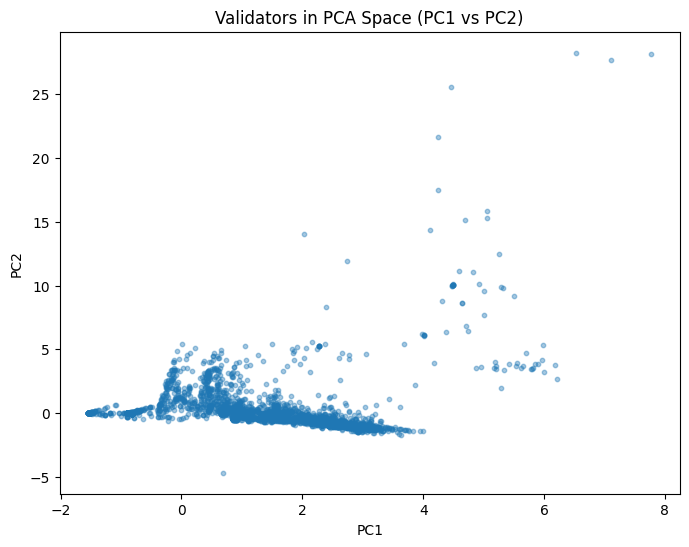

In [ ]:
# Project to First 2 PCs
pca_2 = PCA(n_components=2)

X_pca_2 = pca_2.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca_2,
    columns=["PC1", "PC2"]
)

plt.figure(figsize=(8,6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    alpha=0.4,
    s=10
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Validators in PCA Space (PC1 vs PC2)")

plt.show()

### **PCA Findings**
#### *Keeping 4 Principal Components:*


1.   PC1: Validator Maturity / Scale
2.   Performance Quality
3.   Consistency / Trajectory
4.   Commision Policy



In [ ]:
# Final PCA Representation (4 PCs)

pca_final = PCA(n_components=4)

X_pca = pca_final.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2", "PC3", "PC4"]
)

# Keep validator identifier for later cluster analysis
pca_df["node_pubkey"] = validators["node_pubkey"].values

print(pca_df.shape)
display(pca_df.head())

pca_df.describe()

(8576, 5)


,PC1,PC2,PC3,PC4,node_pubkey
0,1.864375,0.611796,0.373191,-0.285093,BvXzmS5rLW89nHD7K2qVjcERKigDdJ8Xhc74MQZumj9J
1,-1.523991,0.008788,-0.166607,0.420287,G9KGpYSQZxvEZb3YD7qK9wpUvqXcCTfbx278kj4cQC49
2,2.642097,-0.962095,-0.507407,-0.255859,9gFxqsXbFyrKXUkqpAatonn47uYZ7sEZSnMxhzQoXrUJ
3,1.947797,-0.619214,-0.337981,-0.216868,CBUGET5PnvLc3HvEeFYj64iTvdKhYV6pujTPDdDh785K
4,1.086130,0.130192,1.572737,1.277156,2vo82HJubX8Yx2VoCpZupfdtu9miYCrh8A1P3YJXRP25


,PC1,PC2,PC3,PC4
count,8576.000000,8.576000e+03,8.576000e+03,8.576000e+03
mean,0.000000,6.628197e-18,-2.237017e-17,-1.574197e-16
std,1.664288,1.189626e+00,9.823535e-01,9.112927e-01
min,-1.549676,-4.658839e+00,-1.541917e+01,-2.777862e+00
25%,-1.530340,-3.001569e-01,-4.508585e-01,-4.980156e-01
50%,-0.832793,-3.606075e-03,-1.613445e-01,4.157006e-01
75%,1.463292,-3.606075e-03,-6.341263e-02,4.157006e-01
max,7.777202,2.822831e+01,8.045266e+00,5.340523e+00


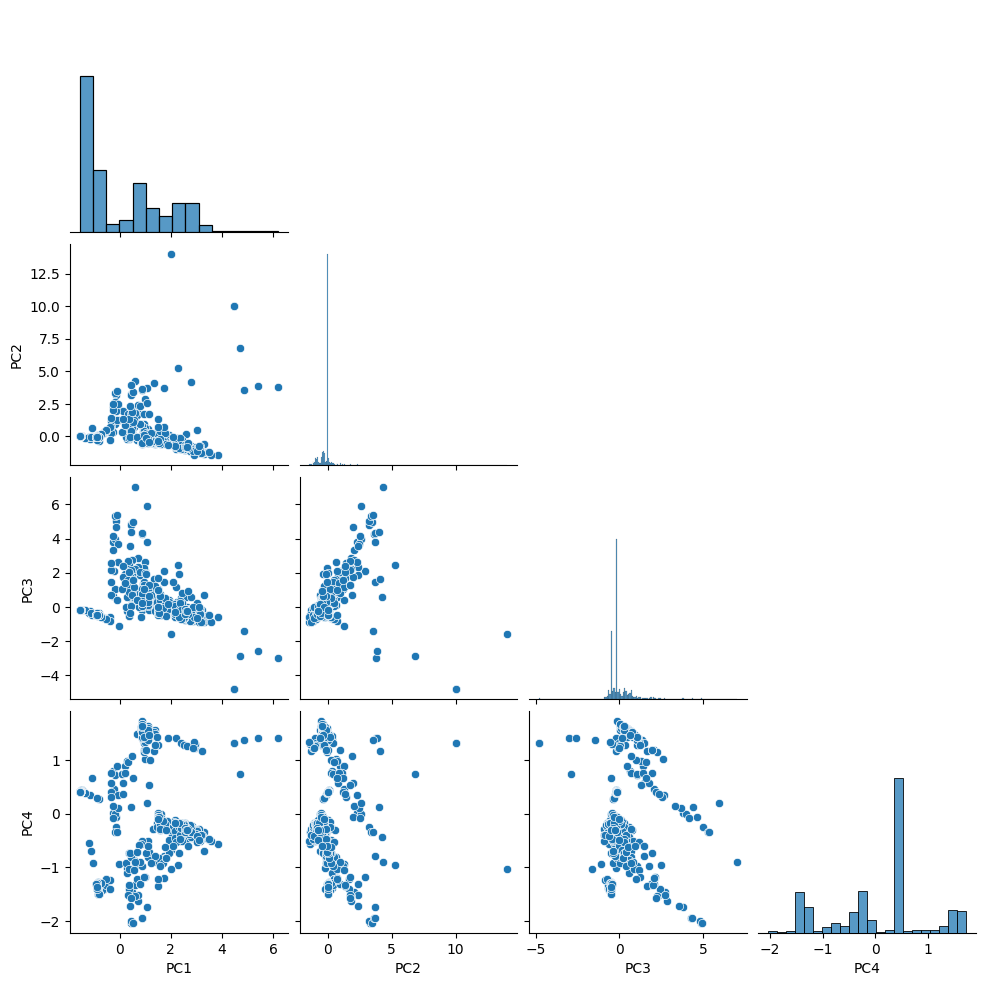

In [ ]:
# Pairwise PCA relationships

import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(
    pca_df[["PC1", "PC2", "PC3", "PC4"]].sample(
        min(1000, len(pca_df)),
        random_state=42
    ),
    corner=True
)

plt.show()

In [ ]:
# Most extreme validators along each dimension

for pc in ["PC1", "PC2", "PC3", "PC4"]:
    print(f"\n{'='*60}")
    print(pc)

    print("\nTop 5:")
    display(
        pca_df.nlargest(5, pc)[
            ["node_pubkey", pc]
        ]
    )

    print("\nBottom 5:")
    display(
        pca_df.nsmallest(5, pc)[
            ["node_pubkey", pc]
        ]
    )


PC1

Top 5:


,node_pubkey,PC1
8362,EhD9y2TQQjULbzoVzVjiNwP16aKN4UTCK1rcJUKSB5J6,7.777202
7651,BTHhx7ckenRvXmL9sd34UQiNRU3txCYDma5ASfA8sfN5,7.105787
7421,Dom1Nby86HyVxAh9bmCZk6Gere2SxbniwTMeXF5SqCEj,6.535443
7635,tYeqa8a29XqdD8xUbL5S1pAaWDt6ADFKCPytqFxPCwL,6.214707
7645,1so1ctTM24PdU7RLZJzJKYYVYri3gjNeCd8nmHbpdXg,6.180255



Bottom 5:


,node_pubkey,PC1
4126,GNLKxNiDNzN7Gw6ug2PU69ojCGriufp1bMsPqP6ncXrd,-1.549676
4127,6t8hzJokvu6BV6t21WE9BUbvTr7YdzAHaCkKcEqcKFtG,-1.549676
4128,6LZ9ZY9mXAMQALFMZbAh8NE4M76XTGEw6WLLdWaszzNm,-1.549676
4129,8qKrKacHZurjPgm8QhBMRkaU6rSBTRKN8ogowfLLw3iH,-1.549676
4130,2iBLV1VdH36XNHyaQZz256hkJRnhnS2D8kjo27EPfxqD,-1.549676



PC2

Top 5:


...

,node_pubkey,PC3
7421,Dom1Nby86HyVxAh9bmCZk6Gere2SxbniwTMeXF5SqCEj,-15.419172
8362,EhD9y2TQQjULbzoVzVjiNwP16aKN4UTCK1rcJUKSB5J6,-15.268818
7651,BTHhx7ckenRvXmL9sd34UQiNRU3txCYDma5ASfA8sfN5,-14.692771
7622,GoLd56YQz8nJQnCsPFw8g5hcxrNaQBvCfAgbtwYFLbd,-13.076542
8371,thorMioHDc25Z2dsPtaNtoe7kmMRBVNC6XXfbwHKpzU,-10.886932



PC4

Top 5:


,node_pubkey,PC4
7651,BTHhx7ckenRvXmL9sd34UQiNRU3txCYDma5ASfA8sfN5,5.340523
8362,EhD9y2TQQjULbzoVzVjiNwP16aKN4UTCK1rcJUKSB5J6,5.262651
7582,CNJCRhkajZ4Nw2yoBDSUjgMkvSRAWMsdhYLA7n6pZQqu,3.369803
7650,3weHX7YvucD2n4Dix37TkD6rSYHp4FQsc7d5iUvhcmqX,3.319195
8368,privaEdSEmnMPGPoQACUkcDGkFBbTArVvsEGd7C5wUM,3.163245



Bottom 5:


,node_pubkey,PC4
7347,pidrcoD3t88h8MzJU2EACHL8A6iMoQqwueXPA8KLwUS,-2.777862
7345,dst2u7mXMyDvb14cSErRNA1mxH1d5VXbSXgZ3DKE9xH,-2.544305
3845,7v4n2945syf163MMc6x4MJDtcNj2GCz1Yr7fWzYnuiV7,-2.533498
539,7FBJQgv1uJgs2397AnWZnjj5DERi1F5VnzDBwjBLrRt4,-2.520565
1750,AuhGb13rqqCJEc8WRXfkm27SujQFdJoZKfKfr4pfrRpE,-2.349670


In [ ]:
pca_df.nlargest(20, "PC2")

,PC1,PC2,PC3,PC4,node_pubkey
7421,6.535443,28.228309,-15.419172,2.784921,Dom1Nby86HyVxAh9bmCZk6Gere2SxbniwTMeXF5SqCEj
8362,7.777202,28.103505,-15.268818,5.262651,EhD9y2TQQjULbzoVzVjiNwP16aKN4UTCK1rcJUKSB5J6
7651,7.105787,27.639478,-14.692771,5.340523,BTHhx7ckenRvXmL9sd34UQiNRU3txCYDma5ASfA8sfN5
7622,4.465542,25.528101,-13.076542,1.627705,GoLd56YQz8nJQnCsPFw8g5hcxrNaQBvCfAgbtwYFLbd
8371,4.240094,21.634576,-10.886932,1.382108,thorMioHDc25Z2dsPtaNtoe7kmMRBVNC6XXfbwHKpzU
8266,4.244140,17.501198,-8.753701,1.412155,AG1PsJMQcutNUX64RD3bAhW7NpxWeFkqkgGizBznYFKW
7314,5.048274,15.858516,-8.153223,1.783515,Hpq4nm4CtYynqiao5mJCFyD4sbiXXEQiSN2JXScJ5rff
7420,5.061589,15.251742,-7.494492,1.714808,hykfH9jUQqe2yqv3VqVAK5AmMYqrmMWmdwDcbfsm6My
7430,4.694095,15.166789,-5.497891,1.114158,84YLEg7HE4rfvamnk7kVayJcX5iWX42jjaDLFg3WTVQA
7582,4.112615,14.354920,-6.229930,3.369803,CNJCRhkajZ4Nw2yoBDSUjgMkvSRAWMsdhYLA7n6pZQqu


## **5) Clustering**

### **5.1) Elbow Method**

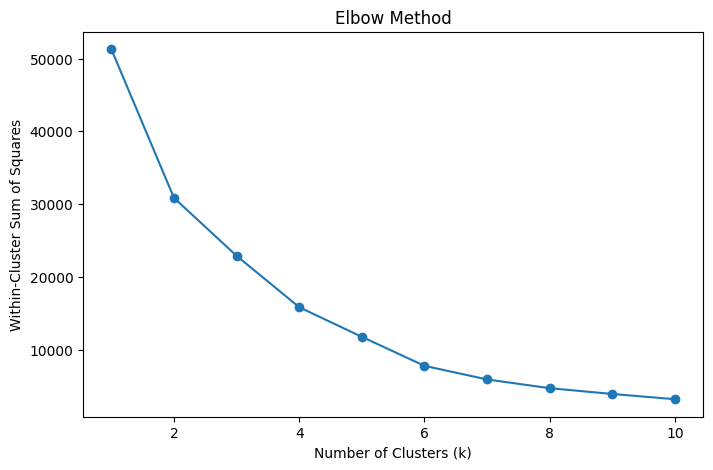

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K = range(1, 11)

for k in K:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    km.fit(pca_df[["PC1","PC2","PC3","PC4"]])

    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Within-Cluster Sum of Squares")
plt.title("Elbow Method")
plt.show()

### **5.1) Silhouette Analysis**

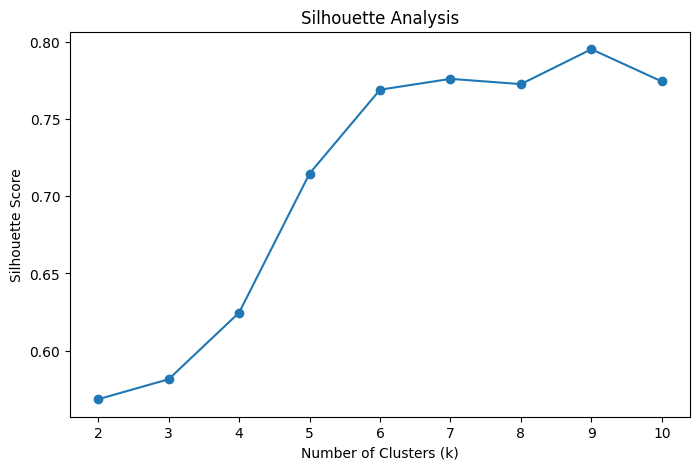

Best k = 9


In [ ]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2,11):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = km.fit_predict(
        pca_df[["PC1","PC2","PC3","PC4"]]
    )

    score = silhouette_score(
        pca_df[["PC1","PC2","PC3","PC4"]],
        labels
    )

    scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), scores, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.show()

print(
    f"Best k = {range(2,11)[scores.index(max(scores))]}"
)

### K = 6
The elbow method showed substantial reductions in within-cluster variance up to approximately k=6, after which improvements diminished. Silhouette analysis similarly improved rapidly through k=6 before plateauing. Based on both criteria, a six-cluster solution was selected for subsequent analysis.

### **5.3) Final Model**

In [ ]:
kmeans = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=10
)

pca_df["cluster"] = kmeans.fit_predict(
    pca_df[["PC1","PC2","PC3","PC4"]]
)

### **5.4) Interpretation**

In [ ]:
# Cluster Sizes
cluster_sizes = (
    pca_df["cluster"]
    .value_counts()
    .sort_index()
)

print(cluster_sizes)
print(cluster_sizes / len(pca_df))

cluster
0    2106
1    3379
2    1083
3      35
4    1625
5     348
Name: count, dtype: int64
cluster
0    0.245569
1    0.394007
2    0.126283
3    0.004081
4    0.189482
5    0.040578
Name: count, dtype: float64


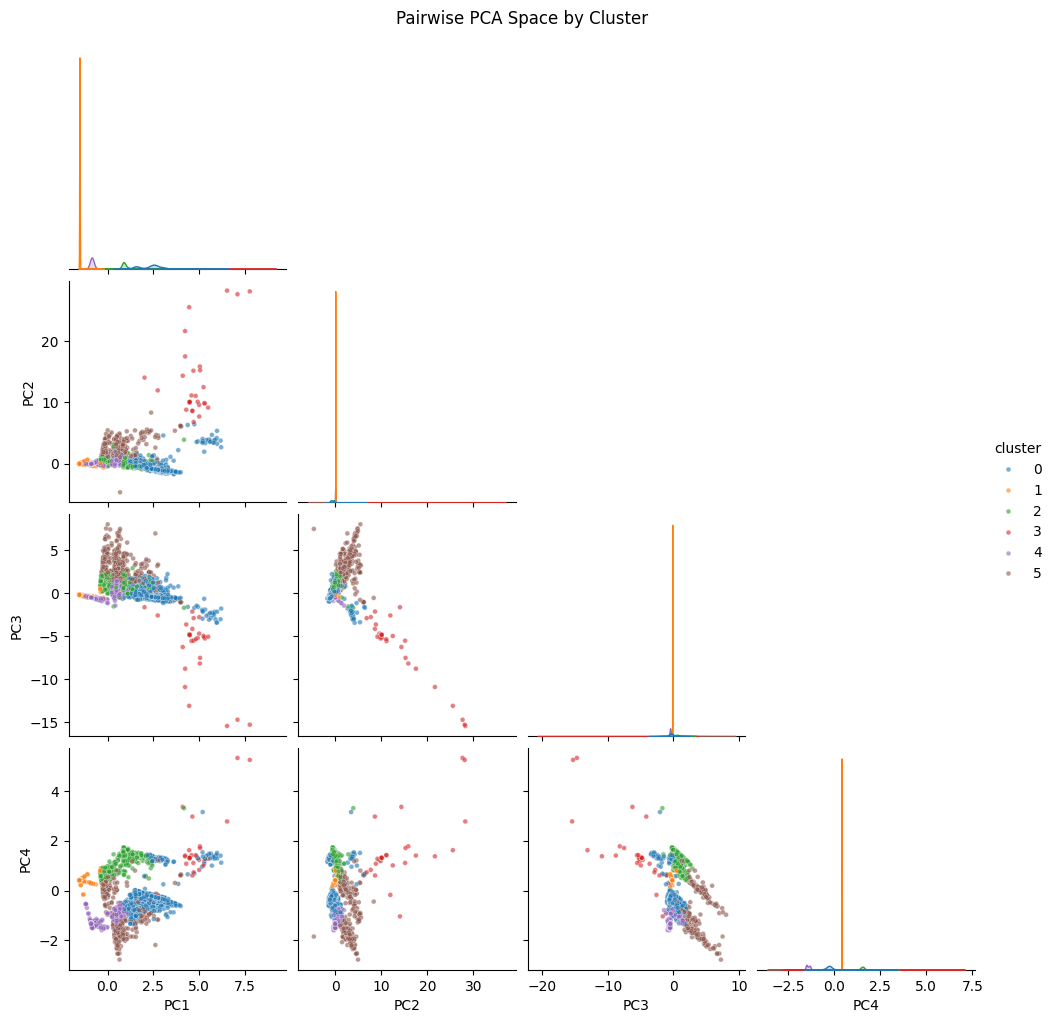

In [ ]:
# Pairwise PCA plots colored by cluster

sns.pairplot(
    pca_df[["PC1", "PC2", "PC3", "PC4", "cluster"]],
    hue="cluster",
    palette="tab10",
    corner=True,
    plot_kws={"alpha": 0.6, "s": 12}
)

plt.suptitle("Pairwise PCA Space by Cluster", y=1.02)
plt.show()

In [ ]:
# Original Features
clustered = validators.copy()

clustered["cluster"] = pca_df["cluster"].values

cluster_profiles = (
    clustered
    .groupby("cluster")[candidate_features]
    .median()
)

display(cluster_profiles.round(3))

,commission,log_lamports,median_efficiency_pct,efficiency_cv,performance_trend,num_epochs_recorded,has_history
cluster,,,,,,,
0,10.0,9.847,5.984,0.092,-0.024,64.0,1.0
1,100.0,7.433,0.000,0.117,0.000,1.0,0.0
2,100.0,7.429,5.427,0.140,-0.401,64.0,1.0
3,0.0,7.433,99.511,0.292,14.122,14.0,1.0
4,5.0,7.433,0.000,0.117,0.000,1.0,0.0
5,10.0,7.433,3.068,0.680,0.000,3.0,1.0


In [ ]:
cluster_profiles_mean = (
    clustered
    .groupby("cluster")[candidate_features]
    .mean()
)

display(cluster_profiles_mean.round(3))

,commission,log_lamports,median_efficiency_pct,efficiency_cv,performance_trend,num_epochs_recorded,has_history
cluster,,,,,,,
0,12.39,9.653,7.100,0.101,-0.017,59.654,1.000
1,99.975,7.439,0.035,0.117,0.000,0.996,0.002
2,99.788,7.723,5.452,0.152,-0.317,58.918,0.999
3,12.314,8.079,89.504,0.427,23.315,15.629,1.000
4,5.02,7.460,0.741,0.124,-0.011,2.036,0.097
5,42.026,7.685,8.693,0.699,-0.093,7.557,1.000


In [ ]:
# Standardized Cluster Profile
cluster_zscores = (
    cluster_profiles
    - cluster_profiles.mean()
) / cluster_profiles.std()

display(cluster_zscores.round(2))

,commission,log_lamports,median_efficiency_pct,efficiency_cv,performance_trend,num_epochs_recorded,has_history
cluster,,,,,,,
0,-0.57,2.04,-0.33,-0.65,-0.40,1.28,0.65
1,1.29,-0.41,-0.48,-0.54,-0.39,-0.76,-1.29
2,1.29,-0.41,-0.34,-0.44,-0.46,1.28,0.65
3,-0.77,-0.41,2.04,0.23,2.04,-0.34,0.65
4,-0.67,-0.41,-0.48,-0.54,-0.39,-0.76,-1.29
5,-0.57,-0.41,-0.40,1.94,-0.39,-0.69,0.65


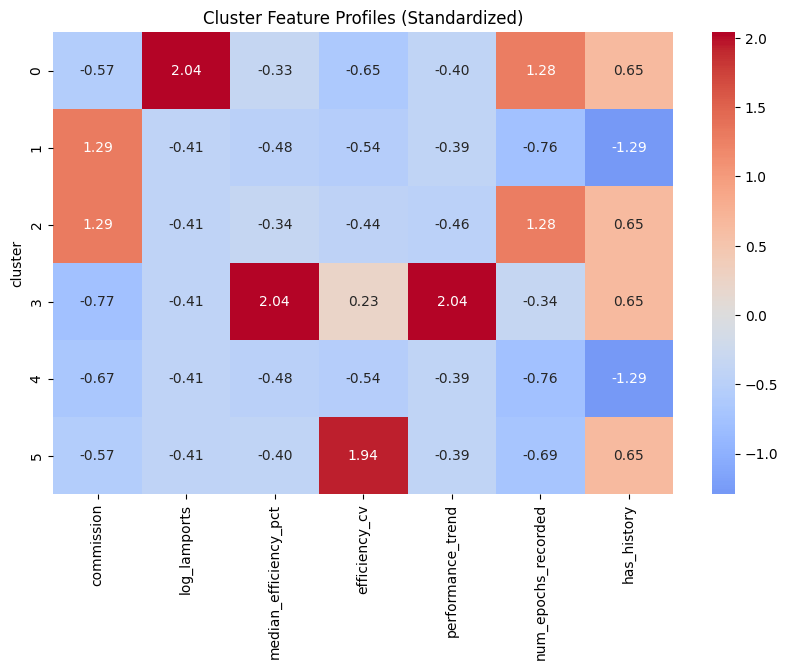

In [ ]:
# Heatmap
cluster_profiles = (
    clustered
    .groupby("cluster")[candidate_features]
    .median()
)

cluster_zscores = (
    cluster_profiles - cluster_profiles.mean()
) / cluster_profiles.std()

cluster_zscores = cluster_zscores.astype(float)

plt.figure(figsize=(10, 6))

sns.heatmap(
    cluster_zscores,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Cluster Feature Profiles (Standardized)")
plt.show()